# Beijing Multi-Site Air Quality — Modelling Methodology Report

**Task.** Predict next-hour PM2.5 (`PM2_5_next_hour`) at 12 Beijing stations. Competition metric: **RMSE**.

**Constraint.** Train includes `current_PM2_5`. The official test file does **not**. Using true current PM2.5 as a test feature is ineligible.

**Approach.** The production script is `temp.py`. LightGBM is trained to predict the **one-hour change**:

\[
\Delta_t = \mathrm{PM2.5}_{t+1} - \mathrm{PM2.5}_t
\]

At test time the true current level is missing, so inference **walks each station forward in time**. The last train hour is forecast first; that value becomes current PM2.5 for the first test hour; each prediction is written into a per-station history and reused as lags. Training features and inference features use the same definitions (`training_matrix` vs `fill_dynamic_features`).

`fixed_model.py` is a comparison hybrid: a weather-only LightGBM (A), a weather + recursive PM2.5-history LightGBM (B), then station bias / shift and a haze boost. It writes `submission_fixed.csv` and does **not** replace the leaderboard file.

An earlier two-stage “reconstruct current PM2.5 from sensors, then boost” pipeline was tried and discarded. It is **not** used to produce `submission.csv`.

Seed **42**. Implementation: `temp.py` (primary), `fixed_model.py` (alternative). Reproduction: `README.md`.


## 1. Setup

Python 3.11. Packages: pandas, numpy, LightGBM, matplotlib; scikit-learn is used by `fixed_model.py`. See `requirements.txt`.

This notebook is the methodology report. It reads **`data/train_cleaned.csv`** and **`data/test_cleaned.csv`** (from `Data Cleaning.ipynb`) and imports functions from `temp.py`. It does not `import fixed_model` (that file runs training on import).


In [1]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import temp as rec
import lightgbm as lgb

ROOT = Path(".")
DATA = ROOT / "data"
OUT = ROOT / "recursive_lightgbm_output"
SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
print("seed", SEED)
print("temp.py lags", rec.LAGS)
print("weather columns", rec.WEATHER_COLUMNS)


/Users/yo/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


seed 42
temp.py lags (1, 2, 3, 6, 12, 24)
weather columns ('PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM')


## 2. Data and train/test protocol

- Train: 1 Mar 2013 – 31 Aug 2016, hourly, 12 stations, target labelled, `current_PM2_5` present.
- Test: 31 Aug 2016 23:00 – 28 Feb 2017, **no** `current_PM2_5`, **no** target.
- Test is entirely after train. Random row splits would leak the future.
- At test time, history is either (a) weather/pollutants on that test row, or (b) **this model’s own previous predictions**.


In [2]:
train_raw = pd.read_csv(DATA / "train_cleaned.csv")
test_raw = pd.read_csv(DATA / "test_cleaned.csv")
if "current_PM2_5" in test_raw.columns:
    test_raw = test_raw.drop(columns=["current_PM2_5"])
train_raw["observation_timestamp"] = pd.to_datetime(train_raw["observation_timestamp"])
test_raw["observation_timestamp"] = pd.to_datetime(test_raw["observation_timestamp"])
print("train", train_raw.shape, train_raw["observation_timestamp"].min(), "→", train_raw["observation_timestamp"].max())
print("test ", test_raw.shape, test_raw["observation_timestamp"].min(), "→", test_raw["observation_timestamp"].max())
print("test has current_PM2_5:", "current_PM2_5" in test_raw.columns)
print("stations", sorted(train_raw["station"].unique()))


train (360954, 20) 2013-03-01 00:00:00 → 2016-08-31 22:00:00
test  (51063, 18) 2016-08-31 23:00:00 → 2017-02-28 22:00:00
test has current_PM2_5: False
stations ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


## 3. Data cleaning and preprocessing

**Step A — `Data Cleaning.ipynb`** (writes the tables this notebook loads)

1. Parse `observation_timestamp`.
2. `wd` missing → `"Missing"`.
3. PM10, gases and weather: fill with **train-only column means** (same means on test).
4. `current_PM2_5`: fill with the train mean, **on train only**. Never written onto test.
5. No row dropping.

**Step B — `temp.py` on those cleaned tables**

1. Sort by station, timestamp. Station–time keys must be unique.
2. Map `wd` to degrees; wind u/v from `WSPM`.
3. Integer `station_code` from the sorted train station list.
4. PM2.5 lags 1–24h only when the timestamp gap is exact; otherwise NaN + missing flag.

Recursive **state** (predicted current PM2.5) is produced by the model, not taken from the test file.



## 4. Feature engineering (`temp.py`)

**Train target:** `PM2_5_next_hour - current_PM2_5` (delta). At inference the delta is added to the recursive current level and clipped at 0.

**Static / test-available**

- `station_code`
- cyclic hour and day-of-year, day-of-week, weekend, heating season (15 Nov–15 Mar)
- PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WSPM and a missing flag for each
- wind u/v, dewpoint spread, stagnant wind (`WSPM < 1.5`)

**Dynamic (true current PM2.5 on train; recursive state on test)**

- `current_pm25`, `pm25_pm10_ratio`
- lags 1, 2, 3, 6, 12, 24 hours (time-aligned) and missing flags
- 1h and 3h differences; mean and std of the lags that exist

`year` is not used (test includes 2017).

**`fixed_model.py` extras (alternative run):** Magus-style humidity, `PM10`/`CO` squares, PM10×CO, stagnation risk, high-PM10/CO/NO2 flags, weather lags 1–24h and 6h rolling mean/max, PM2.5 current/lags/rolling/extreme flag on the history model only.


In [3]:
stations = sorted(train_raw["station"].unique())
train = rec.canonicalize(train_raw, stations)
X_demo, y_demo = rec.training_matrix(train.iloc[:5000].copy())
print("feature count", X_demo.shape[1])
print("delta target: mean", float(np.nanmean(y_demo)), "std", float(np.nanstd(y_demo)))
print("columns:")
print(", ".join(X_demo.columns))


feature count 50
delta target: mean 0.1494113245631653 std 20.91293770018687
columns:
station_code, hour_sin, hour_cos, doy_sin, doy_cos, dayofweek, is_weekend, is_heating_season, current_pm25, wind_u, wind_v, PM10, PM10_missing, SO2, SO2_missing, NO2, NO2_missing, CO, CO_missing, O3, O3_missing, TEMP, TEMP_missing, PRES, PRES_missing, DEWP, DEWP_missing, RAIN, RAIN_missing, WSPM, WSPM_missing, dewpoint_spread, pm25_pm10_ratio, is_stagnant, pm25_lag_1, pm25_lag_1_missing, pm25_lag_2, pm25_lag_2_missing, pm25_lag_3, pm25_lag_3_missing, pm25_lag_6, pm25_lag_6_missing, pm25_lag_12, pm25_lag_12_missing, pm25_lag_24, pm25_lag_24_missing, pm25_diff_1h, pm25_diff_3h, pm25_hist_mean, pm25_hist_std


## 5. Validation strategy

Chronological only.

| Window | Role |
|---|---|
| Fit on **all** labelled train, walk test in time | Production inference (`recursive_predict`) |
| Optional `online.csv` | **Labels only, after inference.** Not used to fit, not written into recursive history. |

The recursive walk **is** the protocol that matches test: each hour’s “current PM2.5” is the previous hour’s prediction, after a one-step warm-start from the last train row.

If a test hour has no history key (gap), the last recursive state is carried forward (`recursive_gap_bridge_rows` in `metrics.json`).

`fixed_model.py` estimates station bias on the last 10% of the concatenated train table (sorted by station, then time). That slice is **not** a clean city-wide chronological holdout, so it is not used for model selection.


## 6. Models tested

| Model | File | Notes |
|---|---|---|
| **Recursive LightGBM delta** | `temp.py` | Train on $\Delta$; walk test with predicted level as next current. **Selected.** |
| Hybrid A/B + station bias | `fixed_model.py` | Model A weather-only (1200 rounds); Model B weather+PM2.5 history (1500 rounds); mix weight on A is $\max(0.15, 1 - i/300)$; subtract station bias; add $0.3\times$ recent-vs-global mean shift; $\times 1.15$ if prediction $>150$. |
| Two-stage sensor proxy + seed-bag | (discarded) | Reconstruct current PM2.5 from PM10/gases, then LightGBM. Not in this repo. |

Post-processing in `temp.py`: `max(0, current + delta)`. No manual row edits.

Set `RETRAIN = True` in the next cell to fit `temp.py` on all train and overwrite `submission.csv`. Prefer `python temp.py` from the shell (saves the booster and metrics the same way as `main()`).


In [4]:
RETRAIN = False  # True = fit recursive LightGBM and write submission.csv

sub_path = ROOT / "submission.csv"
metrics_path = OUT / "metrics.json"

if RETRAIN:
    stations = sorted(train_raw["station"].unique())
    train = rec.canonicalize(train_raw, stations)
    test = rec.canonicalize(test_raw, stations)
    print("Training LightGBM (temp.py train_model)")
    model, features = rec.train_model(train)
    print("Recursive inference")
    preds, bridge_rows = rec.recursive_predict(model, features, train, test)
    sub = test_raw[["id"]].merge(preds[["id", "PM2_5_next_hour"]], on="id", how="left")
    if sub["PM2_5_next_hour"].isna().any() or (sub["PM2_5_next_hour"] < 0).any():
        raise ValueError("Submission validation failed.")
    OUT.mkdir(parents=True, exist_ok=True)
    sub.to_csv(sub_path, index=False)
    sub.to_csv(OUT / "submission_recursive_lightgbm.csv", index=False)
    preds.to_csv(OUT / "recursive_predictions_with_state.csv", index=False)
    model.save_model(str(OUT / "recursive_lightgbm_model.txt"))
    record = {
        "metric": "RMSE",
        "selected_label": "Recursive LightGBM delta (temp.py)",
        "submission_rows": int(len(sub)),
        "recursive_gap_bridge_rows": int(bridge_rows),
        "training_rows": int(len(train)),
        "feature_count": len(features),
        "seed": SEED,
        "num_boost_round": 900,
        "learning_rate": 0.035,
        "num_leaves": 63,
        "min_data_in_leaf": 80,
        "target": "PM2_5_next_hour - current_PM2_5 (delta), added back at inference",
    }
    (OUT / "metrics.json").write_text(json.dumps(record, indent=2) + "\n")
    print("Wrote", sub_path)
    print(json.dumps(record, indent=2))
else:
    if not sub_path.exists():
        raise FileNotFoundError("submission.csv missing. Run: python temp.py")
    sub = pd.read_csv(sub_path)
    record = json.loads(metrics_path.read_text()) if metrics_path.exists() else {
        "selected_label": "Recursive LightGBM delta (temp.py)",
        "note": "metrics.json not found; run python temp.py to write the full artefact set",
        "submission_rows": int(len(sub)),
    }
    print("Loaded", sub_path, "rows", len(sub))
    print(json.dumps(record, indent=2))


Loaded submission.csv rows 51063
{
  "selected_label": "Recursive LightGBM delta (temp.py)",
  "note": "metrics.json not found; run python temp.py to write the full artefact set",
  "submission_rows": 51063
}


## 7. Model selection

**Selected: recursive LightGBM in `temp.py`.** That is the script that writes `submission.csv`.

Why this over `fixed_model.py`:

- Train and test features are the **same definitions**, so recursive current/lags are not an ad-hoc inference-only block.
- The model is asked only for the increment, which is what persistence-plus-weather should learn.
- Missingness is modelled with flags instead of filling sensors with a global median.
- `fixed_model.py` is kept as a stress test (haze boost, station bias). Its 90/10 slice is not a clean chronological holdout.

### Hyperparameters — `temp.py` (submitted)

| Setting | Value |
|---|---|
| booster | native `lgb.train` |
| objective / metric | regression / RMSE |
| learning_rate | 0.035 |
| num_leaves | 63 |
| min_data_in_leaf | 80 |
| feature_fraction / bagging_fraction | 0.85 / 0.85 |
| bagging_freq | 1 |
| lambda_l2 | 1.0 |
| num_boost_round | 900 |
| seeds | 42 (also `feature_fraction_seed`, `bagging_seed`) |
| `num_threads` | −1 at train, 1 at recursive predict |

### Hyperparameters — `fixed_model.py` (comparison)

Both models: `learning_rate=0.02`, `num_leaves=255`, `max_depth=12`, `min_data_in_leaf=30`, `lambda_l1=1`, `lambda_l2=2`, seed 42. Model A 1200 rounds; Model B 1500 rounds.


In [5]:
eligible = pd.DataFrame([
    {"model": "Recursive LightGBM delta (temp.py)", "role": "selected — writes submission.csv"},
    {"model": "Hybrid A/B + bias (fixed_model.py)", "role": "comparison — writes submission_fixed.csv"},
    {"model": "Two-stage proxy LightGBM (discarded)", "role": "not used"},
])
display(eligible)


,model,role
0,Recursive LightGBM delta (temp.py),selected — writes submission.csv
1,Hybrid A/B + bias (fixed_model.py),comparison — writes submission_fixed.csv
2,Two-stage proxy LightGBM (discarded),not used


## 8. Recursion and post-processing

Per station in `temp.py` (`recursive_predict`):

1. Build a timestamp → PM2.5 map from **train** `current_PM2_5`.
2. Predict the last train hour’s next value (warm-start) and insert it at $t_{\mathrm{last}}+1\mathrm{h}$.
3. For each test hour $t$ in time order: current = history[$t$] (or last state if the hour was a gap); fill lags from history; predict delta; `next = max(0, current + delta)`; write `next` into history at $t+1\mathrm{h}$.

No clip to 999. Rows are merged back onto official test `id` order (`validate='one_to_one'` in `temp.py`).

`fixed_model.py` additionally: ensemble weight on weather-only model A starts at 1.0 and decays toward 0.15 over the first 300 test hours of that station; subtracts station bias from the last 10% of concatenated train; adds 30% of (last-1000-hours mean − full-train mean) of current PM2.5; multiplies predictions above 150 by 1.15; `max(0, ·)`.


submission rows 51063 expected 51063
count    51063.000000
mean        95.283126
std         99.450660
min          0.000000
25%         17.804185
50%         62.029164
75%        140.323927
max        722.409089
Name: PM2_5_next_hour, dtype: float64


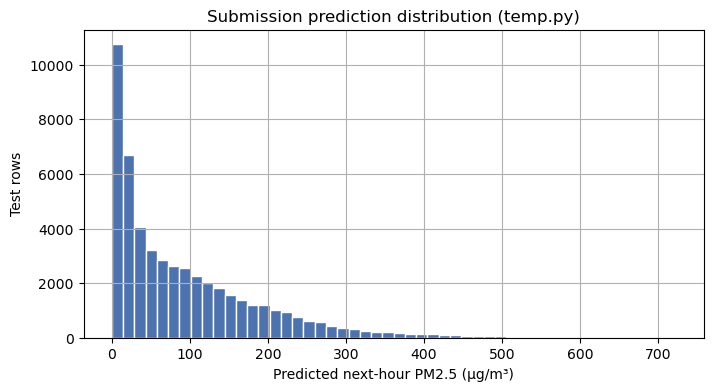

In [6]:
print("submission rows", len(sub), "expected", len(test_raw))
print(sub["PM2_5_next_hour"].describe())
assert list(sub.columns) == ["id", "PM2_5_next_hour"]
assert len(sub) == len(test_raw)
assert sub["id"].tolist() == test_raw["id"].tolist()
assert not sub["PM2_5_next_hour"].isna().any()
assert (sub["PM2_5_next_hour"] >= 0).all()

fig, ax = plt.subplots()
ax.hist(sub["PM2_5_next_hour"], bins=50, color="#4c72b0", edgecolor="white")
ax.set_xlabel("Predicted next-hour PM2.5 (μg/m³)")
ax.set_ylabel("Test rows")
ax.set_title("Submission prediction distribution (temp.py)")
plt.show()


## 9. Final model information

Primary model: **LightGBM booster** from `temp.py` (`lgb.train`, 900 rounds, seed 42). Target is the one-hour delta. Inference is `recursive_predict`.

On `python temp.py`:

- `submission.csv` — leaderboard file
- `recursive_lightgbm_output/recursive_lightgbm_model.txt`
- `recursive_lightgbm_output/metrics.json`
- `recursive_lightgbm_output/recursive_predictions_with_state.csv`


In [7]:
print(json.dumps(record if isinstance(record, dict) else {}, indent=2))
model_path = OUT / "recursive_lightgbm_model.txt"
if model_path.exists():
    booster = lgb.Booster(model_file=str(model_path))
    names = booster.feature_name()
    gain = booster.feature_importance(importance_type="gain")
    imp = pd.DataFrame({"feature": names, "gain": gain}).sort_values("gain", ascending=False).head(20)
    display(imp)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(imp["feature"][::-1], imp["gain"][::-1], color="#4c72b0")
    ax.set_title("Top 20 features — recursive LightGBM (gain)")
    fig.tight_layout()
    plt.show()
else:
    print("No saved booster yet. Run: python temp.py")


{
  "selected_label": "Recursive LightGBM delta (temp.py)",
  "note": "metrics.json not found; run python temp.py to write the full artefact set",
  "submission_rows": 51063
}
No saved booster yet. Run: python temp.py


## 10. Key observations and limitations

- Test has no current PM2.5, so any level feature at test time must be recursive (own preds) or a sensor proxy. This pipeline uses recursion with a delta target.
- Error can compound over a six-month walk. The warm-start from the last train hour and time-aligned lags are meant to limit drift; gaps use last-state carry (`bridge_rows`).
- `fixed_model.py` tries to fight under-prediction of haze (×1.15 above 150) and station bias. Those adjustments are heuristic and can overshoot.
- Optional `online.csv` scoring is **post-inference labels only**. It is not a training input.
- No chemical transport model and no extra monitoring feeds.


## 11. Required disclosure

- **External datasets:** none for fitting. Competition `data/train.csv` / `data/test.csv`, then the cleaned copies from `Data Cleaning.ipynb`. If `online.csv` is present it is used **after** inference to compute a local RMSE, never as a feature or as recursive state.
- **External code / public solutions:** none copied. Heating-season dates, wind u/v, and lagged PM2.5 are standard air-quality features, implemented in `temp.py` / `fixed_model.py`.
- **Pretrained models:** none. LightGBM is trained on this train set.
- **AI tools:** Cursor Grok 4.6 was used to edit the methodology notebook and README so they match `temp.py` and `fixed_model.py`.
- **Manual modification of predictions:** none. `temp.py` clips at 0 only.
- **Additional information:** none beyond the competition files (and optional local `online.csv` labels).


## 12. Reproduction

Full commands: **`README.md`**.

1. `python -m pip install -r requirements.txt`
2. Official `train.csv` and `test.csv` in `data/`
3. Run **`Data Cleaning.ipynb`** → `data/train_cleaned.csv`, `data/test_cleaned.csv`
4. **`python temp.py`** (prefers the cleaned CSVs) writes `submission.csv`
5. Optional comparison: `python fixed_model.py` → `submission_fixed.csv`
6. Or set `RETRAIN = True` above and run this notebook

Do not run any other modelling scripts. `temp.py` and `fixed_model.py` are the source of truth; this notebook does not edit them.
